# GKP-Based Quantum Error Correction in Photonic Systems
**Series:** GKP-QEC (S02)


## Error correction as noise suppression

In S01 we treated the logical noise strength `p` as a direct knob. In this installment we connect that knob to a more physical idea: phase-space displacement noise.

The circuit stays the same. What changes is how we *generate* the effective logical noise strength we feed into it.


### From phase-space noise to logical errors

In photonic systems, a common physical noise process is a small displacement in phase space. We can write it as

$$
D(\epsilon_q, \epsilon_p),
$$

where $\epsilon_q$ and $\epsilon_p$ are small shifts in the position and momentum quadratures of the oscillator.

The GKP code protects against these displacements by measuring syndromes and applying corrective displacements. If a physical displacement exceeds the correction threshold, a logical error occurs.

In this demo we do not simulate the full oscillator dynamics. Instead, we map a *displacement scale* to an effective logical noise strength and study how correction suppresses that logical noise.


### Simple correction model

To keep things simple, we introduce a toy mapping from a displacement scale $\sigma$ to a logical error rate:

$$
p_{\text{raw}}(\sigma) = 1 - e^{-(\sigma / \sigma_0)^2}.
$$

This is not derived from hardware physics. It is just a smooth, monotonic map from a physical noise scale to a logical error probability. The parameter $\sigma_0$ sets the scale.

We then model correction as a suppression of that logical noise:

$$
p_{\text{corrected}} = \alpha \, p_{\text{raw}},
$$

with $\alpha \in (0,1)$. Smaller $\alpha$ means stronger correction.


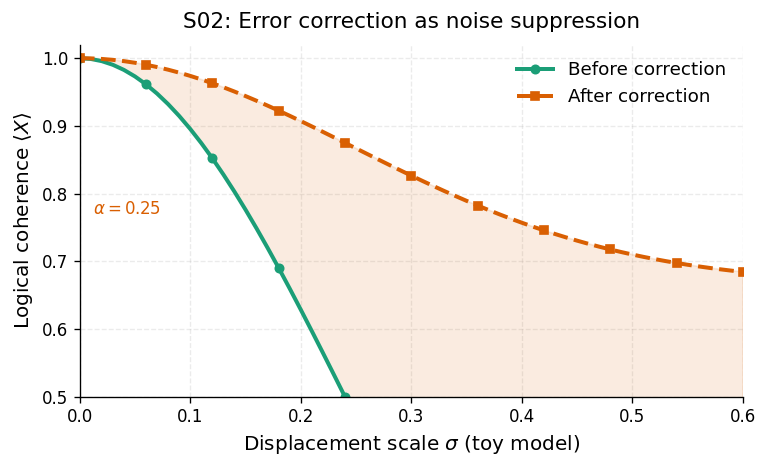

In [1]:
import os

# Ensure a writable Matplotlib cache and a safe backend for notebooks
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib
try:
    from IPython import get_ipython

    if get_ipython() is not None:
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Use a mixed-state simulator to model logical noise
dev = qml.device("default.mixed", wires=1)


def apply_plot_style():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "axes.axisbelow": True,
            "grid.alpha": 0.25,
            "grid.linestyle": "--",
            "axes.labelsize": 12,
            "axes.titlesize": 13,
            "axes.titlepad": 10,
            "legend.frameon": False,
            "legend.fontsize": 11,
            "lines.linewidth": 2.4,
            "lines.markersize": 5,
        }
    )


apply_plot_style()
colors = {
    "raw": "#1b9e77",
    "corrected": "#d95f02",
}


@qml.qnode(dev)
def logical_gkp_coherence(noise_strength):
    """Logical qubit prepared in a superposition and subjected to logical noise."""
    qml.Hadamard(wires=0)
    qml.DepolarizingChannel(noise_strength, wires=0)
    return qml.expval(qml.PauliX(0))


# Physical noise scale (toy model)
sigma = np.linspace(0.0, 0.6, 61)
sigma0 = 0.35

# Map displacement scale to logical noise strength
p_raw = 1.0 - np.exp(-(sigma / sigma0) ** 2)

# Apply correction model (use α consistently with the notation)
α = 0.25
p_corrected = α * p_raw

# Compute coherence
coh_raw = np.array([logical_gkp_coherence(p) for p in p_raw])
coh_corrected = np.array([logical_gkp_coherence(p) for p in p_corrected])

# Plot
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(sigma, coh_raw, "o-", color=colors["raw"], markevery=6, label="Before correction")
ax.plot(sigma, coh_corrected, "s--", color=colors["corrected"], markevery=6, label="After correction")
ax.fill_between(sigma, coh_corrected, coh_raw, color=colors["corrected"], alpha=0.12)
ax.text(0.02, 0.52, rf"$\alpha = {α:.2f}$", transform=ax.transAxes, color=colors["corrected"])

ax.set_xlabel("Displacement scale $\sigma$ (toy model)")
ax.set_ylabel(r"Logical coherence $\langle X \rangle$")
ax.set_title("S02: Error correction as noise suppression")
ax.set_xlim(sigma.min(), sigma.max())
ax.set_ylim(0.5, 1.02)
ax.legend()
fig.tight_layout()
plt.show()


### What to take away

This demo is still software-level, but now the logical noise strength is tied to a physical noise scale. We don’t simulate the oscillator itself, yet we can see how stronger displacement noise leads to lower coherence, and how correction suppresses that effect.
